# The 4th Assignment

Please implement template-based tracking and optical flow-based tracking using video data (either traffic data, person moving, or object motion). Do comparison and analysis from these methods.

Atha Putra Fausta

24/538657/PA/22864

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

The video used will be CCTV recording from Yogyakarta City (Utara Balaikota View Timur).

In [2]:
video_path = "data/cctv.mp4"
cap = cv2.VideoCapture(video_path)

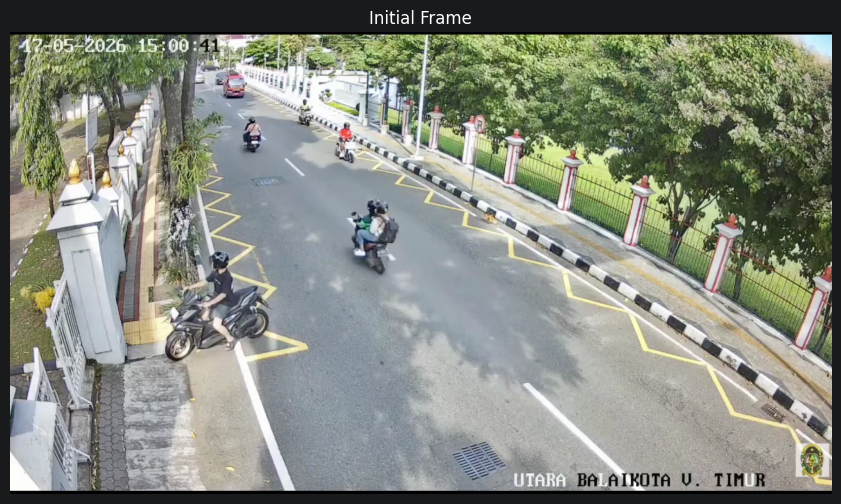

In [3]:
ret, frame = cap.read()
if not ret:
    raise ValueError("Failed to read video")

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))
plt.imshow(frame_rgb)
plt.title("Initial Frame")
plt.axis("off")
plt.show()

The object that will be tracked is red angkot that moves towards the cctv.

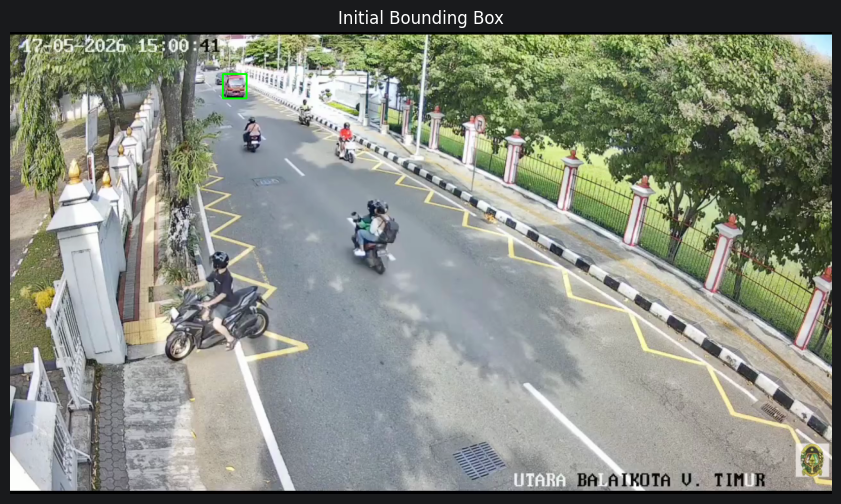

In [4]:
bbox = (331, 65, 37, 38)
x, y, w, h = bbox

frame_vis = frame.copy()

cv2.rectangle(
    frame_vis,
    (x, y),
    (x + w, y + h),
    (0, 255, 0),
    2
)

frame_vis_rgb = cv2.cvtColor(frame_vis, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))
plt.imshow(frame_vis_rgb)
plt.title("Initial Bounding Box")
plt.axis("off")
plt.show()

In [5]:
# convert to grayscale
template_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

template_patch = template_gray[
    y:y+h,
    x:x+w
]

search_margin = 30

Lucas-Kanade method will be used for the optical flow with 9 feature points.

In [6]:
feature_points = [
    (338.0, 72.0),
    (348.0, 72.0),
    (358.0, 72.0),

    (338.0, 84.0),
    (348.0, 84.0),
    (358.0, 84.0),

    (338.0, 96.0),
    (348.0, 96.0),
    (358.0, 96.0),
]

In [7]:
ox, oy, ow, oh = bbox

ox = float(ox)
oy = float(oy)

frame1_gray = cv2.cvtColor(
    frame,
    cv2.COLOR_BGR2GRAY
).astype(np.float32)

window_size = 5
half_window = window_size // 2

5 frames with different object position will be used to compare both method.

In [8]:
sample_frames = [0, 30, 60, 90, 120]

evaluation_frames = {}

In [11]:
cap_template = cv2.VideoCapture(video_path)
cap_optical = cv2.VideoCapture(video_path)

frame_idx = 0

tx, ty, tw, th = bbox

while True:
    # Read next frame
    ret_template, frame_template = cap_template.read()
    ret_optical, frame_optical = cap_optical.read()

    if not ret_template or not ret_optical:
        break

    # TEMPLATE MATCHING
    gray_template = cv2.cvtColor(
        frame_template,
        cv2.COLOR_BGR2GRAY
    )

    x_min = max(0, tx - search_margin)
    y_min = max(0, ty - search_margin)

    x_max = min(gray_template.shape[1] - tw, tx + search_margin)
    y_max = min(gray_template.shape[0] - th, ty + search_margin)

    best_ssd = float('inf')

    best_x = tx
    best_y = ty

    for j in range(y_min, y_max):
        for i in range(x_min, x_max):

            patch = gray_template[
                j:j+th,
                i:i+tw
            ]

            diff = (
                template_patch.astype(np.float32)
                - patch.astype(np.float32)
            )

            ssd = np.sum(diff ** 2)

            if ssd < best_ssd:

                best_ssd = ssd
                best_x = i
                best_y = j

    tx = best_x
    ty = best_y

    template_vis = frame_template.copy()

    cv2.rectangle(
        template_vis,
        (tx, ty),
        (tx + tw, ty + th),
        (0, 255, 0),
        2
    )

    cv2.putText(
        template_vis,
        "Template Matching",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )

    # OPTICAL FLOW
    frame2_gray = cv2.cvtColor(
        frame_optical,
        cv2.COLOR_BGR2GRAY
    ).astype(np.float32)

    Ix = np.zeros_like(frame1_gray)
    Iy = np.zeros_like(frame1_gray)

    for yy in range(1, frame1_gray.shape[0] - 1):
        for xx in range(1, frame1_gray.shape[1] - 1):

            Ix[yy, xx] = (
                frame1_gray[yy, xx + 1]
                - frame1_gray[yy, xx - 1]
            ) / 2.0

            Iy[yy, xx] = (
                frame1_gray[yy + 1, xx]
                - frame1_gray[yy - 1, xx]
            ) / 2.0

    It = frame2_gray - frame1_gray

    new_points = []

    dx_list = []
    dy_list = []

    for (px, py) in feature_points:

        A = []
        b = []

        y_start = int(max(0, py - half_window))
        y_end = int(min(Ix.shape[0] - 1, py + half_window))

        x_start = int(max(0, px - half_window))
        x_end = int(min(Ix.shape[1] - 1, px + half_window))

        for j in range(y_start, y_end + 1):
            for i in range(x_start, x_end + 1):

                ix = Ix[j, i]
                iy = Iy[j, i]
                it = It[j, i]

                A.append([ix, iy])
                b.append([-it])

        A = np.array(A, dtype=np.float32)
        b = np.array(b, dtype=np.float32)

        ATA = A.T @ A
        ATb = A.T @ b

        flow = np.linalg.pinv(ATA) @ ATb

        u = flow[0, 0]
        v = flow[1, 0]

        # Reject unstable motion
        if abs(u) > 10 or abs(v) > 10:
            continue

        new_x = px + u
        new_y = py + v

        new_points.append((new_x, new_y))

        dx_list.append(u)
        dy_list.append(v)

    if len(dx_list) > 0:

        mean_dx = np.mean(dx_list)
        mean_dy = np.mean(dy_list)

        ox += mean_dx
        oy += mean_dy

    optical_vis = frame_optical.copy()

    cv2.rectangle(
        optical_vis,
        (int(ox), int(oy)),
        (int(ox + ow), int(oy + oh)),
        (0, 255, 0),
        2
    )

    for (px, py) in new_points:

        cv2.circle(
            optical_vis,
            (int(px), int(py)),
            3,
            (0, 0, 255),
            -1
        )

    cv2.putText(
        optical_vis,
        "Optical Flow",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )

    feature_points = new_points

    frame1_gray = frame2_gray.copy()

    # SIDE-BY-SIDE COMPARISON
    combined = np.hstack(
        (template_vis, optical_vis)
    )

    if frame_idx in sample_frames:

        evaluation_frames[frame_idx] = combined.copy()

    frame_idx += 1

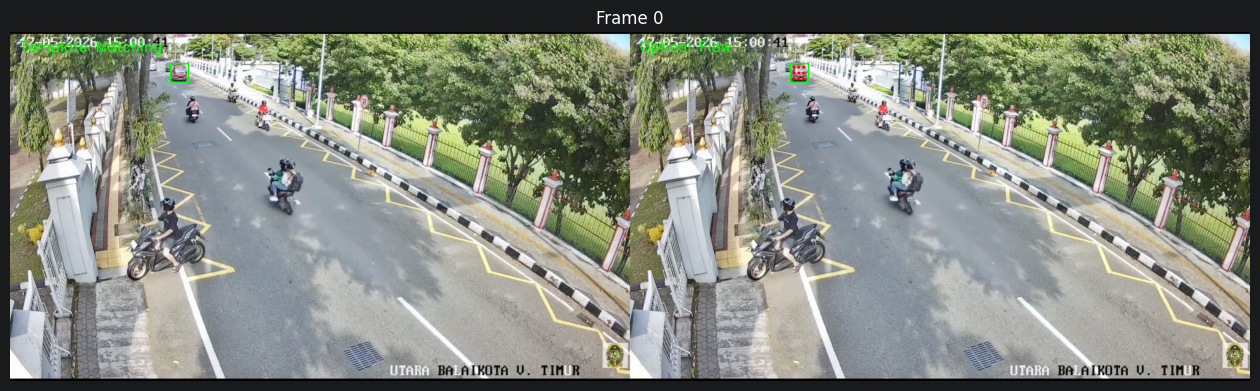

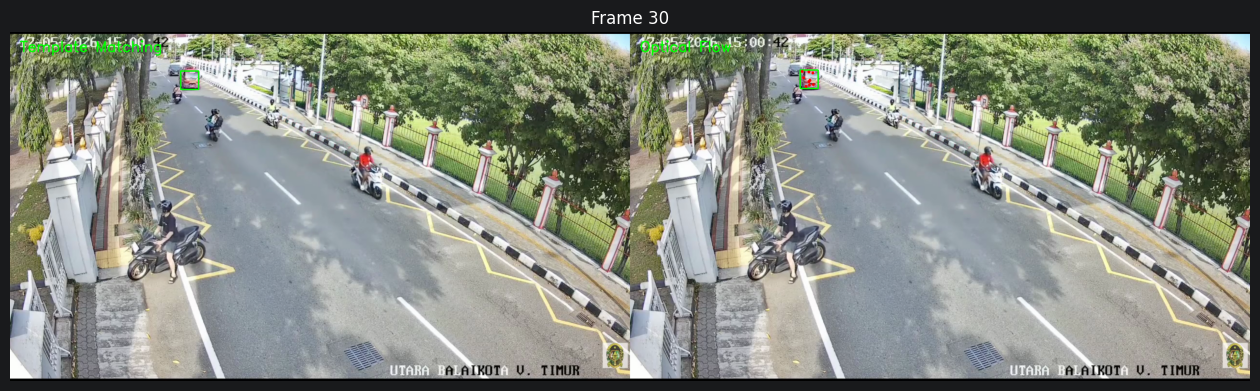

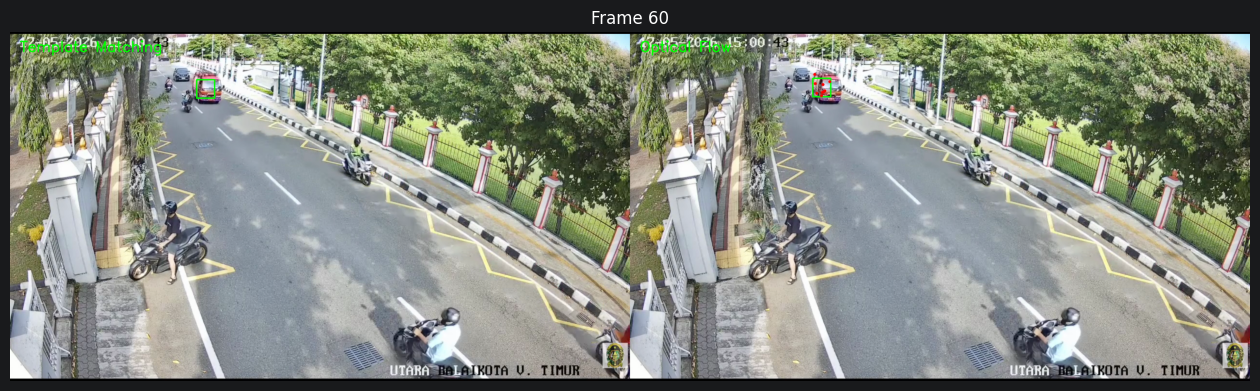

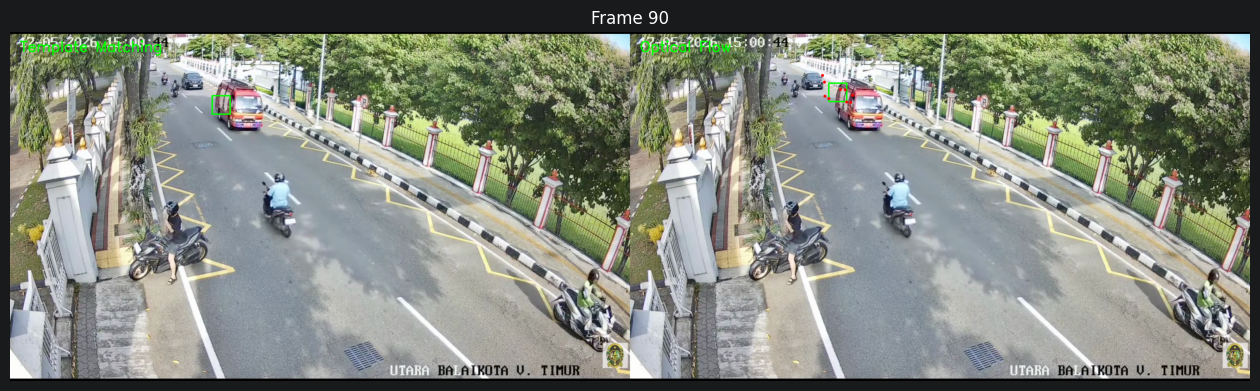

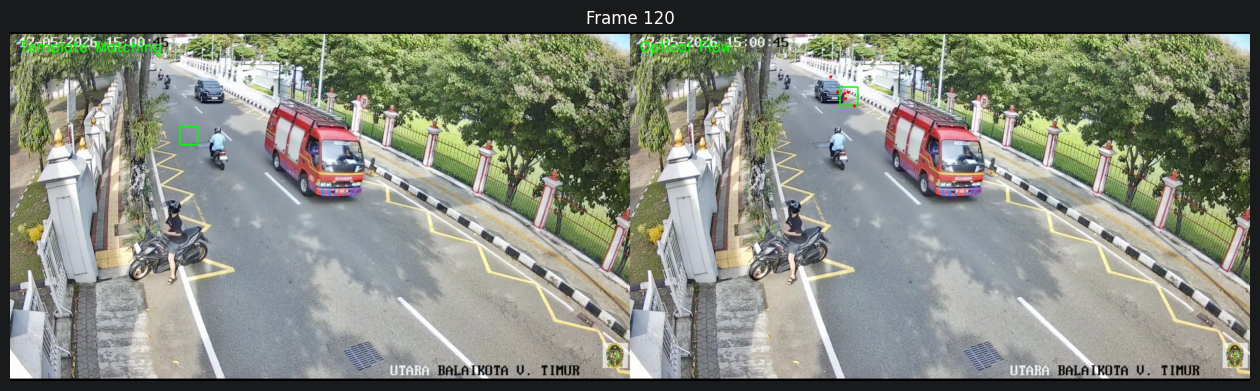

In [13]:
cap_template.release()
cap_optical.release()

for frame_number in sample_frames:

    if frame_number not in evaluation_frames:
        continue

    image = evaluation_frames[frame_number]

    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(16,6))

    plt.imshow(image_rgb)

    plt.title(f"Frame {frame_number}")

    plt.axis("off")

    plt.show()

## Analysis

Both method successfully tracked the red angkot up until frame 60, where the appearance of the angkot is similar to the starting point. However, as the angkot approaches the CCTV, the appearance changed, making the tracker struggles. On frame 90 onwards, the optical flow result showed the bounding box stayed where the angkot is last detected. However, the template matching result showed the bounding box moves around the video frame as it is finding a similar object to the template.